In [ ]:
# Name: Jackson Irungu Maina
# Reg No: ST61/55297/2025
# Programme: ST61 - Master of Data Science
# School: School of Science and Technology
# Course: Data Mining and Big Data , CSA 806 (Year 1 Sem 2 )
# Task: Module 1: Assignment 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:

# Load the dataset
df = pd.read_csv('fiia.csv')

In [3]:
# Filter for Kenya
kenya_data = df[df['country'] == 'Kenya'].copy()

# Features for segmentation: Age, Household Size, Location, Education, Job Type
features = ['age_of_respondent', 'household_size', 'location_type', 'education_level', 'job_type']
data = kenya_data[features].copy()

In [4]:

# Preprocessing
# 1. Handle Categorical Data
le = LabelEncoder()
data['location_type'] = le.fit_transform(data['location_type']) # Rural=0, Urban=1 usually

# For job_type and education_level, we'll use simple label encoding for this academic exercise
# though One-Hot is usually better for non-ordinal.
data['education_level'] = le.fit_transform(data['education_level'])
data['job_type'] = le.fit_transform(data['job_type'])

In [5]:

# 2. Scaling
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

In [12]:

# 3. Clustering - K-Means
# Let's assume 3 segments: High Value, Mass Market, and Young/Emerging
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kenya_data['Cluster'] = kmeans.fit_predict(data_scaled)

In [14]:
# 4. Analysis of Clusters (Robust Version)
# We use a helper function to decide: Mean for numbers, Mode for text/categories.
def aggregate_cluster(x):
    if pd.api.types.is_numeric_dtype(x):
        return x.mean()
    else:
        # For categorical data, we return the most frequent item (mode)
        mode_val = x.mode()
        return mode_val[0] if not mode_val.empty else None

# Grouping and applying our logic to the specific features
cluster_analysis = kenya_data.groupby('Cluster')[features].agg(aggregate_cluster)

print("Refined Cluster Profiles:")
print(cluster_analysis)

Refined Cluster Profiles:
         age_of_respondent  household_size location_type      education_level  \
Cluster                                                                         
0                63.140000        3.062857         Rural    Primary education   
1                33.548934        3.403654         Urban  Secondary education   
2                31.602786        5.100042         Rural    Primary education   

                    job_type  
Cluster                       
0        Farming and Fishing  
1        Informally employed  
2        Farming and Fishing  


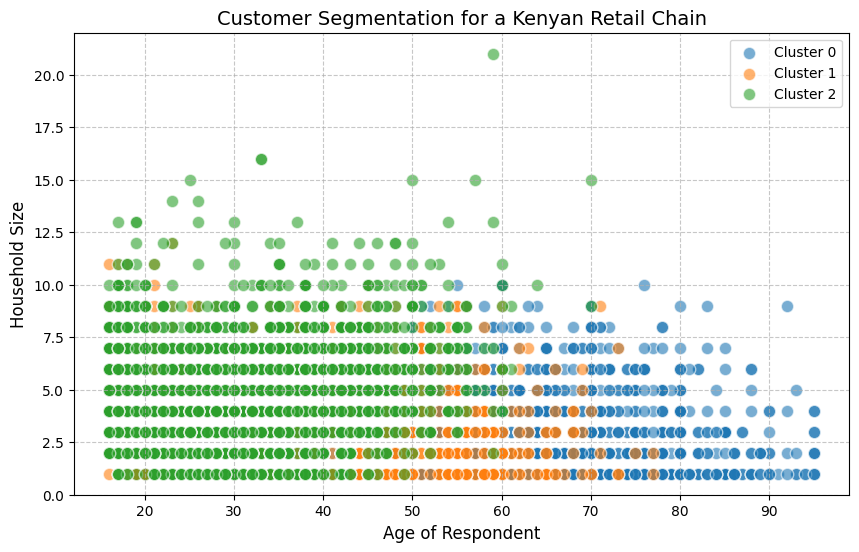

In [15]:
# 5. Visualization - Age vs Household Size (common retail metrics)
plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for cluster in range(3):
    clustered_data = kenya_data[kenya_data['Cluster'] == cluster]
    plt.scatter(clustered_data['age_of_respondent'], clustered_data['household_size'],
                label=f'Cluster {cluster}', alpha=0.6, edgecolors='w', s=80)

plt.title('Customer Segmentation for a Kenyan Retail Chain', fontsize=14)
plt.xlabel('Age of Respondent', fontsize=12)
plt.ylabel('Household Size', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('retail_segmentation.png')

# Save the segmented data for the user
kenya_data.to_csv('kenyan_retail_segmented.csv', index=False)